In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<Axes: >

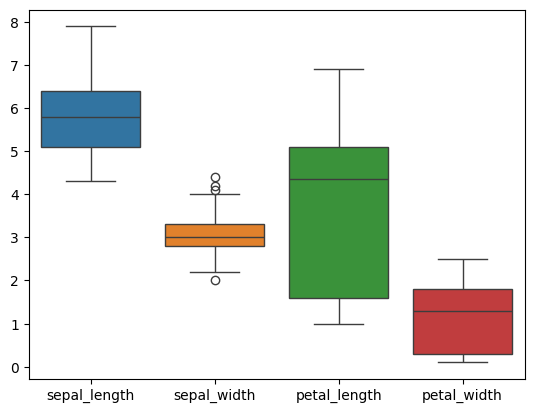

In [5]:
sns.boxplot(data)

In [6]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
X = data.drop("species", axis=1)
y = data["species"]

In [8]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

In [9]:
y = pd.get_dummies(y)
y

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [13]:
y_train

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
mms = MinMaxScaler()
train_temp = mms.fit_transform(X_train)
test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [16]:
mms_X_train

,sepal_length,sepal_width,petal_length,petal_width
22,0.088235,0.666667,0.000000,0.041667
15,0.411765,1.000000,0.087719,0.125000
65,0.705882,0.458333,0.596491,0.541667
11,0.147059,0.583333,0.105263,0.041667
42,0.029412,0.500000,0.052632,0.041667
...,...,...,...,...
71,0.529412,0.333333,0.526316,0.500000
106,0.176471,0.208333,0.614035,0.666667
14,0.441176,0.833333,0.035088,0.041667
92,0.441176,0.250000,0.526316,0.458333


In [17]:
mms_X_test

,sepal_length,sepal_width,petal_length,petal_width
73,0.529412,0.333333,0.649123,0.458333
18,0.411765,0.750000,0.122807,0.083333
118,1.000000,0.250000,1.035088,0.916667
78,0.500000,0.375000,0.614035,0.583333
76,0.735294,0.333333,0.666667,0.541667
31,0.323529,0.583333,0.087719,0.125000
64,0.382353,0.375000,0.456140,0.500000
141,0.764706,0.458333,0.719298,0.916667
68,0.558824,0.083333,0.614035,0.583333
82,0.441176,0.291667,0.508772,0.458333


In [18]:
y_test  # 다중분류

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


# 텐서플로로 다중분류 분석하기

Sequential API

In [19]:
from keras.models import Sequential
from keras.layers import Dense, Input

2025-05-15 23:05:07.704382: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 23:05:07.715389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747317907.728124   12919 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747317907.731685   12919 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747317907.740727   12919 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [20]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation="softmax"))
model.summary()

I0000 00:00:1747317909.719194   12919 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
    * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
    * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding된 경우

Epoch 1/100


I0000 00:00:1747317911.014317   12969 service.cc:152] XLA service 0x7f63a800a810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747317911.014379   12969 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-15 23:05:11.036824: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747317911.187425   12969 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5000 - loss: 1.0063

I0000 00:00:1747317912.182933   12969 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.3946 - loss: 1.0974 - val_accuracy: 0.3000 - val_loss: 1.1624
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3507 - loss: 1.1110 - val_accuracy: 0.3000 - val_loss: 1.1404
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3604 - loss: 1.0999 - val_accuracy: 0.4333 - val_loss: 1.1250
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4070 - loss: 1.1188 - val_accuracy: 0.5667 - val_loss: 1.1148
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5642 - loss: 1.0948 - val_accuracy: 0.6333 - val_loss: 1.1097
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7026 - loss: 1.0757 - val_accuracy: 0.6333 - val_loss: 1.1065
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6991 - loss: 1.0699 - val_accuracy: 0.6333 - val_loss: 1.1030
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6384 - loss: 1.0939 - val_accuracy: 0.6333 - val_loss: 1.0992
Epo

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7104 - loss: 0.7966 - val_accuracy: 0.6333 - val_loss: 0.8024
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7125 - loss: 0.8007 - val_accuracy: 0.6333 - val_loss: 0.7949
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6884 - loss: 0.7955 - val_accuracy: 0.6333 - val_loss: 0.7872
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6555 - loss: 0.7866 - val_accuracy: 0.6333 - val_loss: 0.7798
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6397 - loss: 0.7751 - val_accuracy: 0.6333 - val_loss: 0.7738
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6601 - loss: 0.7716 - val_accuracy: 0.6333 - val_loss: 0.7669
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6022 - loss: 0.7603 - val_accuracy: 0.5667 - val_loss: 0.7601
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5739 - loss: 0.7591 - val_accuracy: 0.5333 - v

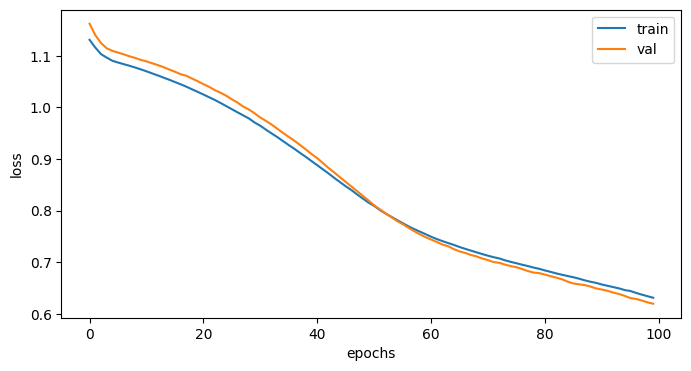

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.002601,0.469945,0.527454
18,True,False,False,0.582600,0.199081,0.218319
118,False,False,True,0.000161,0.428045,0.571794
78,False,True,False,0.002503,0.465096,0.532402
76,False,True,False,0.001462,0.467067,0.531471
31,True,False,False,0.582600,0.199081,0.218319
64,False,True,False,0.008147,0.474100,0.517753
141,False,False,True,0.000614,0.442208,0.557177
68,False,True,False,0.002552,0.467956,0.529492
82,False,True,False,0.005046,0.478007,0.516947


In [21]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

In [22]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [23]:
pd.DataFrame(pred)

,0,1,2
73,0.002601,0.469945,0.527454
18,0.582600,0.199081,0.218319
118,0.000161,0.428045,0.571794
78,0.002503,0.465096,0.532402
76,0.001462,0.467067,0.531471
31,0.582600,0.199081,0.218319
64,0.008147,0.474100,0.517753
141,0.000614,0.442208,0.557177
68,0.002552,0.467956,0.529492
82,0.005046,0.478007,0.516947


Funtional API

In [24]:
from keras.models import Model

In [25]:
inputs = Input(shape=(mms_X_train.shape[1],))
x = Dense(16, activation='relu')(inputs)
x = Dense(8, activation='relu')(x)
x = Dense(4, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.2756 - loss: 1.1249 - val_accuracy: 0.3000 - val_loss: 1.0694
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3428 - loss: 1.0526 - val_accuracy: 0.4000 - val_loss: 1.0163
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3750 - loss: 1.0090 - val_accuracy: 0.3667 - val_loss: 0.9854
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3242 - loss: 0.9924 - val_accuracy: 0.3667 - val_loss: 0.9631
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2983 - loss: 0.9860 - val_accuracy: 0.3667 - val_loss: 0.9401
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2951 - loss: 0.9678 - val_accuracy: 0.4000 - val_loss: 0.9202
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3645 - loss: 0.9269 - val_accuracy: 0.5000 - val_loss: 0.9022
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5716 - loss: 0.9207 - val_accuracy: 0.6000 - val_loss

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9679 - loss: 0.2732 - val_accuracy: 0.9667 - val_loss: 0.2508
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9574 - loss: 0.2728 - val_accuracy: 0.9667 - val_loss: 0.2446
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9419 - loss: 0.2610 - val_accuracy: 0.9667 - val_loss: 0.2386
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9806 - loss: 0.2315 - val_accuracy: 0.9667 - val_loss: 0.2325
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9488 - loss: 0.2575 - val_accuracy: 0.9667 - val_loss: 0.2266
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9653 - loss: 0.2345 - val_accuracy: 0.9667 - val_loss: 0.2235
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9490 - loss: 0.2383 - val_accuracy: 0.9667 - val_loss: 0.2155
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9492 - loss: 0.2402 - val_accuracy: 0.9667 - v

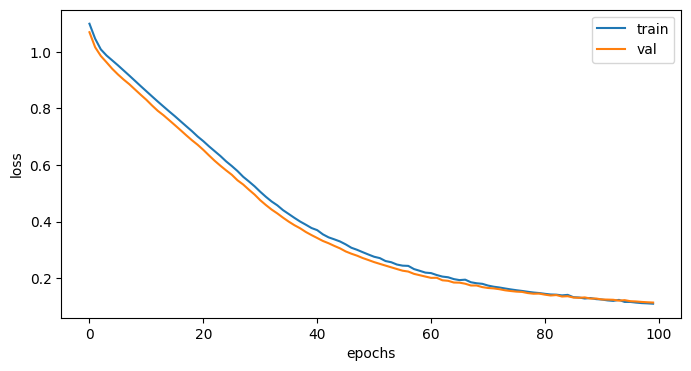

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,1.647039e-03,0.936229,0.062124
18,True,False,False,9.961426e-01,0.003564,0.000294
118,False,False,True,1.542849e-07,0.000592,0.999408
78,False,True,False,1.459946e-03,0.827072,0.171468
76,False,True,False,7.333184e-04,0.753595,0.245671
31,True,False,False,9.909571e-01,0.008290,0.000753
64,False,True,False,4.529932e-03,0.961487,0.033984
141,False,False,True,1.428971e-05,0.026340,0.973646
68,False,True,False,7.902601e-04,0.258608,0.740602
82,False,True,False,3.236797e-03,0.958931,0.037833


In [26]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

Subclass API

In [27]:
class Iris(Model):
    def __init__(self):
        super(Iris, self).__init__()
        self.dense1 = Dense(16, activation='relu')
        self.dense2 = Dense(8, activation='relu')        
        self.dense3 = Dense(4, activation='relu')
        self.classifier = Dense(3, activation='softmax')
        
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)        
        return self.classifier(x)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.3607 - loss: 1.1097 - val_accuracy: 0.3000 - val_loss: 1.1049
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2909 - loss: 1.1033 - val_accuracy: 0.3000 - val_loss: 1.0923
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3516 - loss: 1.0743 - val_accuracy: 0.3000 - val_loss: 1.0825
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3858 - loss: 1.0578 - val_accuracy: 0.4667 - val_loss: 1.0748
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4941 - loss: 1.0483 - val_accuracy: 0.5000 - val_loss: 1.0678
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6094 - loss: 1.0474 - val_accuracy: 0.5667 - val_loss: 1.0590
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6956 - loss: 1.0365 - val_accuracy: 0.6333 - val_loss: 1.0490
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6458 - loss: 1.0412 - val_accuracy: 0.6333 - val_loss

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6931 - loss: 0.4776 - val_accuracy: 0.6333 - val_loss: 0.4844
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6398 - loss: 0.5006 - val_accuracy: 0.6333 - val_loss: 0.4797
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7305 - loss: 0.4419 - val_accuracy: 0.6333 - val_loss: 0.4754
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7076 - loss: 0.4326 - val_accuracy: 0.6333 - val_loss: 0.4696
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7030 - loss: 0.4444 - val_accuracy: 0.6000 - val_loss: 0.4641
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6359 - loss: 0.4461 - val_accuracy: 0.6000 - val_loss: 0.4584
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6921 - loss: 0.4582 - val_accuracy: 0.6000 - val_loss: 0.4533
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7567 - loss: 0.4302 - val_accuracy: 0.7667 - v

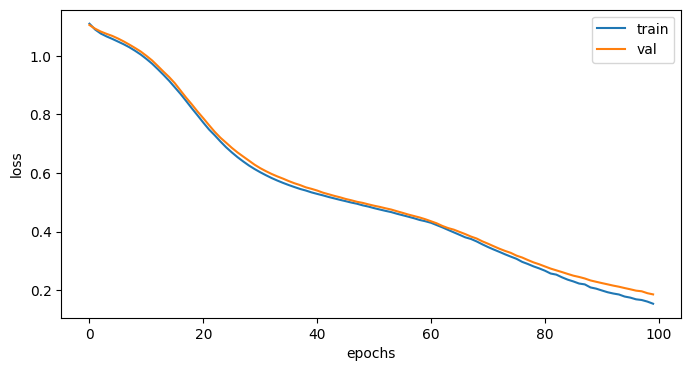

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.003777,0.892494,1.037284e-01
18,True,False,False,0.996755,0.003245,1.239947e-08
118,False,False,True,0.000005,0.090157,9.098380e-01
78,False,True,False,0.002108,0.813785,1.841073e-01
76,False,True,False,0.000355,0.558895,4.407503e-01
31,True,False,False,0.992539,0.007461,1.360312e-07
64,False,True,False,0.034194,0.942697,2.310980e-02
141,False,False,True,0.000012,0.102785,8.972035e-01
68,False,True,False,0.000121,0.158834,8.410452e-01
82,False,True,False,0.013952,0.933593,5.245521e-02


In [28]:
model2 = Iris()
model2.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model2.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model2.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result